# Multi-Label Customer Complaint Classification — Full Pipeline

End-to-end pipeline for classifying customer complaints.

**Stages:**
1. **Sampling** — draw a representative sample from the raw CSV  
2. **Cleaning & Preprocessing** — select, rename, clean, deduplicate  
3. **Label Processing** — build multi-label targets with `MultiLabelBinarizer`  
4. **Train / Val / Test Split**  
5. **Baseline Model** — TF-IDF + Logistic Regression (One-vs-Rest)  
6. **BERT Model** — fine-tuned `bert-base-uncased` for multi-label classification  
7. **Evaluation & Comparison**  
8. **Save Outputs**  
9. **Inference on New Complaints**

---
## Dataset Source & Project Overview

### Raw Data
The dataset used in this project is the official **Consumer Complaint Database**
published by the **Consumer Financial Protection Bureau (CFPB)**:

> **Source:** <https://www.consumerfinance.gov/data-research/consumer-complaints/>

The full dataset contains millions of real-world financial complaints submitted
by US consumers, covering products such as mortgages, credit cards, student loans,
and more.

### Data Pipeline (Pre-executed Offline)

| Stage | Description | Output |
|-------|-------------|--------|
| **Download** | Full dataset downloaded from the CFPB portal | `complaints.csv` (~3 M rows) |
| **Sampling** | 20 % random sample per 100 K-row chunk, capped at 100 000 rows | `sample2.csv` |
| **Preprocessing** | Column selection · text cleaning · label construction · deduplication | `cleaned_sample.csv` |
| **Upload to Drive** | Final cleaned file uploaded to Google Drive for persistent cloud storage | `MyDrive/Complaints Project/cleaned_sample.csv` |

### Current Notebook Execution

> ✅ **Steps 1 and 2 below are kept for full documentation purposes only.**  
> They show exactly how the raw data was sampled and cleaned — no re-execution needed.  
> **Actual execution begins at [Step 3 — Load Preprocessed Data]**, which mounts  
> Google Drive and reads `cleaned_sample.csv` directly from the cloud — no local  
> uploads, no re-sampling, no re-cleaning.

## Imports

In [1]:
import subprocess, sys, importlib

def run(cmd):
    subprocess.check_call(cmd, shell=True)

def check_package(pkg_name, min_version=None):
    try:
        mod = importlib.import_module(pkg_name)
        if min_version:
            from packaging import version
            current = getattr(mod, '__version__', '0')
            return version.parse(current) >= version.parse(min_version)
        return True
    except ImportError:
        return False

# ── اكتشاف الـ GPU ────────────────────────────────────────────────────────
import torch

def get_gpu_arch():
    try:
        if not torch.cuda.is_available():
            return 'cpu'
        name = torch.cuda.get_device_name(0).lower()
        if any(x in name for x in ['blackwell', 'b100', 'b200', 'b300', 'rtx pro 4000']):
            return 'blackwell'
        if any(x in name for x in ['ada', 'rtx 40', '4090', '4080', '4070', '4060']):
            return 'ada'
        if any(x in name for x in ['ampere', 'rtx 30', '3090', '3080', 'a100', 'a10']):
            return 'ampere'
        return 'other'
    except:
        return 'other'

arch      = get_gpu_arch()
torch_ver = torch.__version__
gpu_name  = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU'

print(f"🖥️  GPU   : {gpu_name}")
print(f"⚡ Arch  : {arch}")
print(f"🔢 CUDA  : {torch.version.cuda}")
print(f"🔥 Torch : {torch_ver}")

# ── تحديد النسخة المطلوبة حسب الـ GPU ────────────────────────────────────
TORCH_CONFIGS = {
    'blackwell': {
        'torch_pkg':   'torch==2.6.0 torchvision==0.21.0',
        'whl':         'https://download.pytorch.org/whl/cu124',
        'trans_pkg':   'transformers>=4.38.0',
        'trans_check': ('transformers', '4.38.0'),
        'torch_min':   '2.6',
    },
    'ada': {
        'torch_pkg':   'torch==2.1.0 torchvision==0.16.0',
        'whl':         'https://download.pytorch.org/whl/cu121',
        'trans_pkg':   'transformers==4.36.0',
        'trans_check': ('transformers', '4.36.0'),
        'torch_min':   '2.1',
    },
    'ampere': {
        'torch_pkg':   'torch==2.1.0 torchvision==0.16.0',
        'whl':         'https://download.pytorch.org/whl/cu121',
        'trans_pkg':   'transformers==4.36.0',
        'trans_check': ('transformers', '4.36.0'),
        'torch_min':   '2.1',
    },
    'other': {
        'torch_pkg':   'torch==2.1.0 torchvision==0.16.0',
        'whl':         'https://download.pytorch.org/whl/cu121',
        'trans_pkg':   'transformers==4.36.0',
        'trans_check': ('transformers', '4.36.0'),
        'torch_min':   '2.1',
    },
    'cpu': {
        'torch_pkg':   'torch==2.1.0 torchvision==0.16.0',
        'whl':         'https://download.pytorch.org/whl/cpu',
        'trans_pkg':   'transformers==4.36.0',
        'trans_check': ('transformers', '4.36.0'),
        'torch_min':   '2.1',
    },
}

config    = TORCH_CONFIGS[arch]
torch_min = config['torch_min']
current   = '.'.join(torch_ver.split('+')[0].split('.')[:2])

torch_ok = tuple(int(x) for x in current.split('.')) >= tuple(int(x) for x in torch_min.split('.'))
trans_ok = check_package(*config['trans_check'])

base_pkgs_ok = all(check_package(m) for m in ['pandas', 'numpy', 'matplotlib', 'sklearn', 'tqdm', 'ipywidgets'])

print(f"\n📋 Status:")
print(f"   Base packages : {'✓' if base_pkgs_ok else '✗ missing'}")
print(f"   PyTorch       : {'✓' if torch_ok else f'✗ need {torch_min}+'}")
print(f"   Transformers  : {'✓' if trans_ok else '✗ missing'}")

# ── إذا كل شي تمام، لا تعمل شي ──────────────────────────────────────────
if base_pkgs_ok and torch_ok and trans_ok:
    print("\n✅ Everything is ready — skipping installation")

else:
    print("\n⚙️  Installing missing packages...")

    if not base_pkgs_ok:
        print("   → Installing base packages...")
        run("pip install -q pandas numpy matplotlib scikit-learn tqdm jupyterlab ipywidgets --root-user-action=ignore")

    if not torch_ok:
        print(f"   → Installing PyTorch for {arch}...")
        run(f"pip install {config['torch_pkg']} --index-url {config['whl']} -q --root-user-action=ignore")

    if not trans_ok:
        print("   → Installing Transformers...")
        run(f"pip install '{config['trans_pkg']}' -q --root-user-action=ignore")

    print("\n✅ Installation complete — restarting kernel and continuing automatically...")

    from IPython.core.display import display, Javascript
    display(Javascript("""
        setTimeout(function() {
            Jupyter.notebook.kernel.restart();
        }, 1000);
        setTimeout(function() {
            Jupyter.notebook.execute_cells_below();
        }, 8000);
    """))

🖥️  GPU   : NVIDIA RTX 4000 Ada Generation
⚡ Arch  : ada
🔢 CUDA  : 12.4
🔥 Torch : 2.4.1+cu124

📋 Status:
   Base packages : ✗ missing
   PyTorch       : ✓
   Transformers  : ✗ missing

⚙️  Installing missing packages...
   → Installing base packages...



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip


   → Installing Transformers...



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip



✅ Installation complete — restarting kernel and continuing automatically...


/tmp/ipykernel_371/1016039435.py:118: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, Javascript


<IPython.core.display.Javascript object>

In [1]:
import os
import ast
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    classification_report,
)

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

from transformers import (
    BertTokenizerFast,
    BertModel,
    get_linear_schedule_with_warmup,
)
from tqdm.auto import tqdm


/usr/local/lib/python3.11/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.11/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


---
## Mount Google Drive

Mount Google Drive to access the pre-processed dataset stored in the cloud.
Run this cell once per session — you will be prompted to authorise access.

---
## Step 1 — Sampling &nbsp; *(Documentation Only — Pre-executed)*

> ⚠️ **This step was executed offline before this notebook session.**  
> The code is shown here for transparency and reproducibility.  
> **Output already saved to disk:** `sample2.csv`

Read `complaints.csv` in 100 K-row chunks, keep only rows with a consumer
narrative, draw 20 % from each chunk, cap at 100 000 rows, save as `sample2.csv`.

```python
RAW_CSV    = 'complaints.csv'
SAMPLE_CSV = 'sample2.csv'
SAMPLE_N   = 100_000
CHUNK_SIZE = 100_000

chunks = []

for chunk in pd.read_csv(RAW_CSV, chunksize=CHUNK_SIZE):
    chunk = chunk.dropna(subset=['Consumer complaint narrative'])
    if len(chunk) > 0:
        chunks.append(chunk.sample(frac=0.2, random_state=42))

df_sample = pd.concat(chunks, ignore_index=True)

# Cap at SAMPLE_N if we ended up with more rows
if len(df_sample) > SAMPLE_N:
    df_sample = df_sample.sample(n=SAMPLE_N, random_state=42)

print(f'Sample shape: {df_sample.shape}')
df_sample.to_csv(SAMPLE_CSV, index=False)
print(f'Saved -> {SAMPLE_CSV}')
```

---
## Step 2 — Data Cleaning & Preparation &nbsp; *(Documentation Only — Pre-executed)*

> ⚠️ **This step was executed offline before this notebook session.**  
> The code is shown here for transparency and reproducibility.  
> **Output already saved to disk:** `cleaned_sample.csv`

Load `sample2.csv`, select the four relevant columns, rename them, drop missing/
empty narratives, fill NA label columns, and remove duplicate rows.

```python
CLEANED_CSV = 'cleaned_sample.csv'

df = pd.read_csv(SAMPLE_CSV)
print('Shape before cleaning:', df.shape)

# ── Select & rename ───────────────────────────────────────────────────────
df = df[['Consumer complaint narrative', 'Product', 'Issue', 'Sub-issue']]
df = df.rename(columns={
    'Consumer complaint narrative': 'text',
    'Product':   'product',
    'Issue':     'issue',
    'Sub-issue': 'sub_issue',
})

# ── Drop rows with no narrative ───────────────────────────────────────────
df = df.dropna(subset=['text'])
df['text'] = df['text'].astype(str).str.strip()
df = df[df['text'] != '']

# ── Fill missing label columns ────────────────────────────────────────────
df['product']   = df['product'].fillna('')
df['issue']     = df['issue'].fillna('')
df['sub_issue'] = df['sub_issue'].fillna('')

# ── Remove duplicates ─────────────────────────────────────────────────────
df = df.drop_duplicates()

print('Shape after  cleaning:', df.shape)
print('Null texts    :', df['text'].isnull().sum())
print('Empty texts   :', (df['text'] == '').sum())
print('Duplicate rows:', df.duplicated().sum())
df.head()
```

---
# ▶ Active Execution Starts Here

The two preprocessing steps above (Sampling, Cleaning) were performed in advance
and their outputs are already saved on disk. This notebook **loads the final
cleaned dataset directly** and proceeds with label processing, model training,
and evaluation.

---

---
## Step 3 — Load Final Preprocessed Dataset from Google Drive

Read `cleaned_sample.csv` directly from Google Drive — the file produced by the
offline preprocessing pipeline and uploaded once to the cloud.

> **No local upload required.**  
> **No re-sampling or re-cleaning performed.**  
> **File location:** `MyDrive/Complaints Project/cleaned_sample.csv`

Adjust `DRIVE_PROJECT_PATH` below if your Drive folder name differs.

In [2]:
# ── Google Drive path configuration ─────────────────────────────────────
CLEANED_CSV = '/workspace/MultiLabel/cleaned_sample.csv'

# ── Load dataset ─────────────────────────────────────────────────────────
df = pd.read_csv(CLEANED_CSV)

print(f'File loaded  : {CLEANED_CSV}')
print(f'Shape        : {df.shape}')
print(f'Columns      : {df.columns.tolist()}')
print(f'\nNull values per column:')
print(df.isnull().sum())
print(f'\nFirst 5 rows:')
display(df.head())

File loaded  : /workspace/MultiLabel/cleaned_sample.csv
Shape        : (81806, 5)
Columns      : ['text', 'product', 'issue', 'sub_issue', 'labels']

Null values per column:
text            0
product         0
issue           0
sub_issue    8109
labels          0
dtype: int64

First 5 rows:


,text,product,issue,sub_issue,labels
0,Yes I got an alert from XXXX XXXX saying I had...,"Credit reporting, credit repair services, or o...",Improper use of your report,Credit inquiries on your report that you don't...,"['Credit reporting, credit repair services, or..."
1,In accordance with the Fair Credit Reporting a...,"Credit reporting, credit repair services, or o...",Improper use of your report,Reporting company used your report improperly,"['Credit reporting, credit repair services, or..."
2,In accordance with the Fair Credit Reporting a...,Credit reporting or other personal consumer re...,Improper use of your report,Reporting company used your report improperly,['Credit reporting or other personal consumer ...
3,I'm really not sure what happened. I have mail...,"Credit reporting, credit repair services, or o...",Problem with a credit reporting company's inve...,Their investigation did not fix an error on yo...,"['Credit reporting, credit repair services, or..."
4,I went to XXXX College in XXXX XXXX XXXX XXXX ...,Student loan,Dealing with my lender or servicer,Don't agree with fees charged,"['Student loan', 'Dealing with my lender or se..."


In [3]:
print(type(df))
print(df.columns.tolist())

<class 'pandas.DataFrame'>
['text', 'product', 'issue', 'sub_issue', 'labels']


=== Basic Info ===
Shape: (81806, 5)

Columns: ['text', 'product', 'issue', 'sub_issue', 'labels']

=== Missing Values ===
text            0
product         0
issue           0
sub_issue    8109
labels          0
dtype: int64

=== Label Analysis ===

Total unique labels: 432

Top 10 labels:
labels
Credit reporting or other personal consumer reports                                 29969
Incorrect information on your report                                                24340
Credit reporting, credit repair services, or other personal consumer reports        19475
Information belongs to someone else                                                 13635
Improper use of your report                                                         12787
Debt collection                                                                     10009
Reporting company used your report improperly                                        9297
Their investigation did not fix an error on your report                

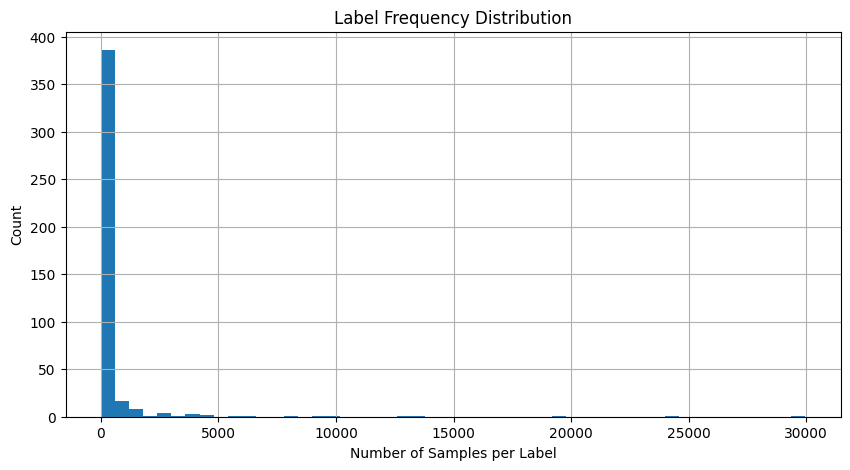


=== Rare Labels ===
Labels with < 10 samples: 96
Labels with < 50 samples: 230
Labels with < 100 samples: 285

=== Labels per Sample ===
count    81806.000000
mean         2.900875
std          0.298831
min          2.000000
25%          3.000000
50%          3.000000
75%          3.000000
max          3.000000
Name: num_labels, dtype: float64


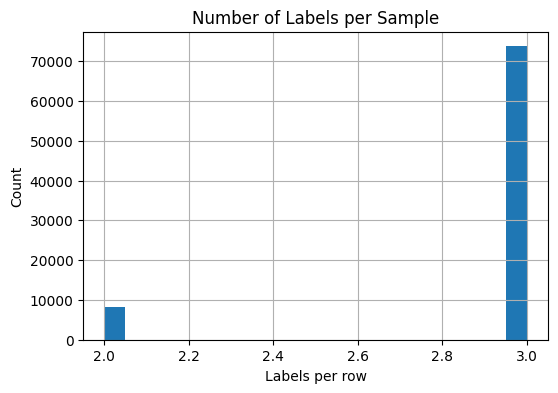


=== Text Length ===
count    81806.000000
mean       195.535768
std        237.739180
min          1.000000
25%         70.000000
50%        131.000000
75%        242.000000
max       6014.000000
Name: text_length, dtype: float64


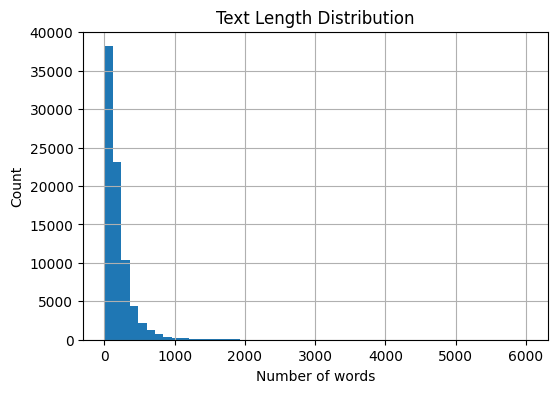


=== Duplicates ===
Duplicate texts: 1029

=== Coverage Insight ===

Labels covering < 0.01% of data:
86


In [4]:
# حوّل labels إلى list فقط إذا كانت string
if isinstance(df['labels'].iloc[0], str):
    df['labels'] = df['labels'].apply(ast.literal_eval)

print("=== Basic Info ===")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

print("\n=== Missing Values ===")
print(df.isnull().sum())

# ─────────────────────────────────────────────
# 🔹 Label Analysis
# ─────────────────────────────────────────────

print("\n=== Label Analysis ===")

all_labels = df['labels'].explode()
label_counts = all_labels.value_counts()

print("\nTotal unique labels:", len(label_counts))
print("\nTop 10 labels:")
print(label_counts.head(10))

print("\nBottom 10 labels:")
print(label_counts.tail(10))

# ─────────────────────────────────────────────
# 🔹 Distribution Plot
# ─────────────────────────────────────────────

plt.figure(figsize=(10, 5))
label_counts.hist(bins=50)
plt.title("Label Frequency Distribution")
plt.xlabel("Number of Samples per Label")
plt.ylabel("Count")
plt.show()

# ─────────────────────────────────────────────
# 🔹 Rare Labels Analysis
# ─────────────────────────────────────────────

print("\n=== Rare Labels ===")
print("Labels with < 10 samples:", (label_counts < 10).sum())
print("Labels with < 50 samples:", (label_counts < 50).sum())
print("Labels with < 100 samples:", (label_counts < 100).sum())

# ─────────────────────────────────────────────
# 🔹 Samples per row (multi-label)
# ─────────────────────────────────────────────

df['num_labels'] = df['labels'].apply(len)

print("\n=== Labels per Sample ===")
print(df['num_labels'].describe())

plt.figure(figsize=(6, 4))
df['num_labels'].hist(bins=20)
plt.title("Number of Labels per Sample")
plt.xlabel("Labels per row")
plt.ylabel("Count")
plt.show()

# ─────────────────────────────────────────────
# 🔹 Text Length Analysis
# ─────────────────────────────────────────────

df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

print("\n=== Text Length ===")
print(df['text_length'].describe())

plt.figure(figsize=(6, 4))
df['text_length'].hist(bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Count")
plt.show()

# ─────────────────────────────────────────────
# 🔹 Duplicate check
# ─────────────────────────────────────────────

duplicates = df.duplicated(subset=['text']).sum()
print("\n=== Duplicates ===")
print("Duplicate texts:", duplicates)

# ─────────────────────────────────────────────
# 🔹 Coverage check
# ─────────────────────────────────────────────

print("\n=== Coverage Insight ===")
total_samples = len(df)
label_coverage = label_counts / total_samples

print("\nLabels covering < 0.01% of data:")
print((label_coverage < 0.0001).sum())

In [5]:
# ===============================
# 🔥 REMOVE RARE LABELS
# ===============================

MIN_SAMPLES = 200  # جرب 50 أو 100

# حساب تكرار كل label
all_labels = df['labels'].explode()
label_counts = all_labels.value_counts()

# اختيار labels القوية فقط
valid_labels = label_counts[label_counts >= MIN_SAMPLES].index

# فلترة labels داخل كل صف
df['labels'] = df['labels'].apply(
    lambda x: [l for l in x if l in valid_labels]
)

# حذف الصفوف اللي صارت فاضية
df = df[df['labels'].map(len) > 0]

print("✅ New dataset shape:", df.shape)
print("✅ Remaining labels:", len(valid_labels))

✅ New dataset shape: (81618, 7)
✅ Remaining labels: 101


---
## Step 4 — Label Processing

The `labels` column loaded from the Drive file is stored as a Python-list string
(e.g. `"['Mortgage', 'Loan modification']"`). We parse it back to an actual list
with `ast.literal_eval`, then encode all labels with `MultiLabelBinarizer`.

In [6]:
# ── Parse labels column (string → list) ─────────────────────────────────
if isinstance(df['labels'].iloc[0], str):
    df['labels'] = df['labels'].apply(ast.literal_eval)

print(df[['text', 'labels']].head())
print('Total rows:', df.shape[0])

# ── Unique label statistics ───────────────────────────────────────────────
all_labels = set(lbl for row in df['labels'] for lbl in row)
print(f'\nUnique labels : {len(all_labels)}')
print('Sample labels :', list(all_labels)[:10])

# ── MultiLabelBinarizer ───────────────────────────────────────────────────
mlb = MultiLabelBinarizer()
y   = mlb.fit_transform(df['labels'])

print(f'\nLabel matrix shape : {y.shape}')
print(f'Classes (first 10) : {list(mlb.classes_[:10])}')

                                                text  \
0  Yes I got an alert from XXXX XXXX saying I had...   
1  In accordance with the Fair Credit Reporting a...   
2  In accordance with the Fair Credit Reporting a...   
3  I'm really not sure what happened. I have mail...   
4  I went to XXXX College in XXXX XXXX XXXX XXXX ...   

                                              labels  
0  [Credit reporting, credit repair services, or ...  
1  [Credit reporting, credit repair services, or ...  
2  [Credit reporting or other personal consumer r...  
3  [Credit reporting, credit repair services, or ...  
4  [Student loan, Dealing with my lender or servi...  
Total rows: 81618

Unique labels : 101
Sample labels : ['Mortgage', 'Old information reappears or never goes away', 'Bank account or service', 'Threatened or suggested your credit would be damaged', 'Overdrafts and overdraft fees', 'Public record information inaccurate', 'You told them to stop contacting you, but they keep trying',

---
## Step 5 — Train / Validation / Test Split

* 80 % **train** + 20 % **test**  
* From the training set, hold out a further 10 % as **validation**.

In [7]:
X = df['text'].tolist()
Y = y

# ── Primary split: train / test ───────────────────────────────────────────
X_train_full, X_test, Y_train_full, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# ── Secondary split: train / val ─────────────────────────────────────────
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_full, Y_train_full, test_size=0.1, random_state=42
)

print(f'X_train : {len(X_train):>7}  Y_train : {Y_train.shape}')
print(f'X_val   : {len(X_val):>7}  Y_val   : {Y_val.shape}')
print(f'X_test  : {len(X_test):>7}  Y_test  : {Y_test.shape}')

X_train :   58764  Y_train : (58764, 101)
X_val   :    6530  Y_val   : (6530, 101)
X_test  :   16324  Y_test  : (16324, 101)


---
## Step 6 — Baseline Model: TF-IDF + Logistic Regression (One-vs-Rest)

In [8]:
import os, pickle

TFIDF_MODEL_PATH   = 'tfidf_lr_model.pkl'
TFIDF_RESULTS_PATH = 'tfidf_results.pkl'

if os.path.exists(TFIDF_MODEL_PATH) and os.path.exists(TFIDF_RESULTS_PATH):
    # ── تحميل من الديسك ───────────────────────────────────────────────────
    print("✓ TF-IDF + LR found on disk — skipping training")
    with open(TFIDF_MODEL_PATH, 'rb') as f:
        tfidf, lr_clf = pickle.load(f)
    with open(TFIDF_RESULTS_PATH, 'rb') as f:
        experiments = pickle.load(f)
    threshold    = 0.30
    X_test_tfidf = tfidf.transform(X_test)
    Y_test_proba = lr_clf.predict_proba(X_test_tfidf)
    Y_pred_test  = (Y_test_proba >= threshold).astype(int)
    print("Results loaded successfully.")

else:
    # ── تدريب من الصفر (أول مرة فقط) ─────────────────────────────────────
    experiments = []

    tfidf = TfidfVectorizer(
        max_features=20_000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=2,
    )
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_val_tfidf   = tfidf.transform(X_val)
    X_test_tfidf  = tfidf.transform(X_test)

    threshold = 0.30
    C         = 1.0

    lr_clf = OneVsRestClassifier(
        LogisticRegression(
            max_iter=1000,
            C=C,
            solver='lbfgs',
            class_weight='balanced'
        ),
        n_jobs=-1,
    )
    lr_clf.fit(X_train_tfidf, Y_train)
    Y_test_proba = lr_clf.predict_proba(X_test_tfidf)
    Y_pred_test  = (Y_test_proba >= threshold).astype(int)

    print('=' * 75)
    print(f'FINAL MODEL — TF-IDF + LR + balanced + C={C} + threshold={threshold}')
    print('=' * 75)
    print(classification_report(
        Y_test,
        Y_pred_test,
        target_names=mlb.classes_,
        zero_division=0
    ))

    experiments.append({
        'name':            'FINAL_TFIDF_LR',
        'model':           'LR',
        'tfidf':           '(1,2), max_features=20000',
        'threshold':       threshold,
        'class_weight':    'balanced',
        'C':               C,
        'precision_micro': precision_score(Y_test, Y_pred_test, average='micro', zero_division=0),
        'recall_micro':    recall_score   (Y_test, Y_pred_test, average='micro', zero_division=0),
        'f1_micro':        f1_score       (Y_test, Y_pred_test, average='micro', zero_division=0),
        'f1_macro':        f1_score       (Y_test, Y_pred_test, average='macro', zero_division=0),
        'f1_weighted':     f1_score       (Y_test, Y_pred_test, average='weighted', zero_division=0),
    })

    df = pd.DataFrame(experiments)
    print("\n=== Final Model Summary ===")
    print(df)

    # ── حفظ على الديسك ────────────────────────────────────────────────────
    with open(TFIDF_MODEL_PATH, 'wb') as f:
        pickle.dump((tfidf, lr_clf), f)
    with open(TFIDF_RESULTS_PATH, 'wb') as f:
        pickle.dump(experiments, f)
    print("✓ TF-IDF + LR saved to disk")

✓ TF-IDF + LR found on disk — skipping training
Results loaded successfully.


---
## Step 7 — BERT Model

### 7.1 — Configuration

In [9]:
NUM_LABELS = Y_train.shape[1]

BERT_MODEL_NAME = 'bert-base-uncased'
MAX_SEQ_LEN     = 256   # 🔥 نرفعها (أفضل للنصوص الطويلة)
BATCH_SIZE      = 16    # ممتاز للـ 4090
NUM_EPOCHS      = 4     # ⚠️ أول تشغيل فقط (تجربة)
LEARNING_RATE   = 2e-5
WARMUP_RATIO    = 0.1
THRESHOLD       = 0.5   # نعدله لاحقًا
DROPOUT_PROB    = 0.3

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'NUM_LABELS : {NUM_LABELS}')
print(f'Device     : {DEVICE}')
print('\nConfiguration:')
for k, v in dict(
    model=BERT_MODEL_NAME,
    max_len=MAX_SEQ_LEN,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    warmup=WARMUP_RATIO,
    threshold=THRESHOLD,
    dropout=DROPOUT_PROB,
).items():
    print(f'  {k:<15} {v}')

NUM_LABELS : 101
Device     : cuda

Configuration:
  model           bert-base-uncased
  max_len         256
  batch_size      16
  epochs          4
  lr              2e-05
  warmup          0.1
  threshold       0.5
  dropout         0.3


### 7.2 — Tokenisation & Dataset

In [10]:
tokenizer = BertTokenizerFast.from_pretrained(BERT_MODEL_NAME)


class ComplaintDataset(Dataset):
    """PyTorch Dataset — tokenises text on the fly."""

    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.float),
        }


def make_loader(texts, labels, shuffle=False):
    ds = ComplaintDataset(texts, labels, tokenizer, MAX_SEQ_LEN)
    return DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=True
    )


# إذا Y_* sparse matrix استخدم toarray()
Y_train_arr = Y_train.astype('float32')
Y_val_arr   = Y_val.astype('float32')
Y_test_arr  = Y_test.astype('float32')

train_loader = make_loader(X_train, Y_train_arr, shuffle=True)
val_loader   = make_loader(X_val,   Y_val_arr)
test_loader  = make_loader(X_test,  Y_test_arr)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Train batches : 3673
Val   batches : 409
Test  batches : 1021


### 7.3 — Model Architecture

In [11]:
class BertMultiLabelClassifier(nn.Module):
    """
    bert-base-uncased backbone with a two-layer classification head.
    Returns raw logits — sigmoid is applied externally during loss/prediction.
    """

    def __init__(self, model_name: str, num_labels: int, dropout: float = 0.3):
        super().__init__()
        self.bert = BertModel.from_pretrained(model_name)
        hidden = self.bert.config.hidden_size

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden // 2, num_labels),
        )

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = out.pooler_output
        return self.classifier(pooled)


model = BertMultiLabelClassifier(
    model_name=BERT_MODEL_NAME,
    num_labels=NUM_LABELS,
    dropout=DROPOUT_PROB,
).to(DEVICE)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total parameters     : {total:,}')
print(f'Trainable parameters : {trainable:,}')

Total parameters     : 109,816,421
Trainable parameters : 109,816,421


### 7.4 — Loss, Optimizer & Scheduler

In [12]:
# ── Weighted BCE loss (handles class imbalance) ───────────────────────────
label_counts = Y_train_arr.sum(axis=0)
neg_counts   = len(Y_train_arr) - label_counts

pos_weight_np = neg_counts / (label_counts + 1e-8)
pos_weight_np = np.clip(pos_weight_np, 1, 20)
pos_weight    = torch.tensor(pos_weight_np, dtype=torch.float).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ── AdamW — skip weight decay on bias & LayerNorm ────────────────────────
no_decay = ['bias', 'LayerNorm.weight']
param_groups = [
    {
        'params': [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
        'weight_decay': 0.01
    },
    {
        'params': [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
        'weight_decay': 0.0
    },
]

optimizer = AdamW(param_groups, lr=LEARNING_RATE)

total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

print(f'Total training steps : {total_steps}')
print(f'Warmup steps         : {warmup_steps}')

Total training steps : 14692
Warmup steps         : 1469


### 7.5 — Training Loop

In [13]:
def evaluate(model, loader, threshold=THRESHOLD):
    """Return (avg_loss, micro_f1, macro_f1, predictions, true_labels)."""
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            lbls = batch['labels'].to(DEVICE)

            logits = model(ids, mask)
            total_loss += criterion(logits, lbls).item()

            preds = (torch.sigmoid(logits) >= threshold).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(lbls.cpu().numpy())

    preds_all  = np.vstack(all_preds)
    labels_all = np.vstack(all_labels)
    avg_loss   = total_loss / len(loader)
    micro_f1   = f1_score(labels_all, preds_all, average='micro', zero_division=0)
    macro_f1   = f1_score(labels_all, preds_all, average='macro', zero_division=0)

    return avg_loss, micro_f1, macro_f1, preds_all, labels_all


# ── Training ──────────────────────────────────────────────────────────────
history = {
    'train_loss': [],
    'val_loss': [],
    'val_f1_micro': [],
    'val_f1_macro': []
}

best_val_macro_f1 = 0.0
best_model_path = 'bert_v3_filtered200.pt'

if os.path.exists(best_model_path):
    print(f'✓ BERT v1 found — skipping training, loading from {best_model_path}')
    model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
    history = {'train_loss': [0]*NUM_EPOCHS, 'val_loss': [0]*NUM_EPOCHS,
               'val_f1_micro': [0]*NUM_EPOCHS, 'val_f1_macro': [0]*NUM_EPOCHS}
else:
    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        running_loss = 0.0
    
        for step, batch in enumerate(train_loader, 1):
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            lbls = batch['labels'].to(DEVICE)
    
            optimizer.zero_grad(set_to_none=True)
            logits = model(ids, mask)
            loss = criterion(logits, lbls)
            loss.backward()
    
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    
            optimizer.step()
            scheduler.step()
    
            running_loss += loss.item()
    
            if step % 20 == 0 or step == len(train_loader):
                print(
                    f'  Epoch {epoch}/{NUM_EPOCHS}  '
                    f'Step {step:>4}/{len(train_loader)}  '
                    f'Loss {running_loss / step:.4f}',
                    end='\r'
                )
    
        train_loss = running_loss / len(train_loader)
        val_loss, val_f1_micro, val_f1_macro, _, _ = evaluate(model, val_loader)
    
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1_micro'].append(val_f1_micro)
        history['val_f1_macro'].append(val_f1_macro)
    
        print(
            f'\nEpoch {epoch}/{NUM_EPOCHS}  '
            f'Train Loss: {train_loss:.4f}  '
            f'Val Loss: {val_loss:.4f}  '
            f'Val micro-F1: {val_f1_micro:.4f}  '
            f'Val macro-F1: {val_f1_macro:.4f}'
        )
    
        if val_f1_macro > best_val_macro_f1:
            best_val_macro_f1 = val_f1_macro
            torch.save(model.state_dict(), best_model_path)
            print(f'  ✔ Best model saved (val macro-F1={best_val_macro_f1:.4f})')

print('\nTraining complete.')

✓ BERT v1 found — skipping training, loading from bert_v3_filtered200.pt


/tmp/ipykernel_831/904174866.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))



Training complete.



## 7.6 — BERT Threshold Tuning

In [14]:
# نحسب احتمالات (probabilities) من الموديل على validation
model.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    for batch in val_loader:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbls = batch['labels'].to(DEVICE)

        logits = model(ids, mask)
        probs  = torch.sigmoid(logits).cpu().numpy()

        all_probs.append(probs)
        all_labels.append(lbls.cpu().numpy())

probs_all  = np.vstack(all_probs)
labels_all = np.vstack(all_labels)

# نجرب thresholds مختلفة
thresholds = np.arange(0.1, 0.9, 0.05)

best_threshold = 0.5
best_f1 = 0.0

print("🔍 Searching best threshold...\n")

for t in thresholds:
    preds = (probs_all >= t).astype(int)
    f1 = f1_score(labels_all, preds, average='micro', zero_division=0)

    print(f"Threshold: {t:.2f} | Micro-F1: {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("\n✅ Best Threshold:", best_threshold)
print("✅ Best Micro-F1:", best_f1)

🔍 Searching best threshold...

Threshold: 0.10 | Micro-F1: 0.2339
Threshold: 0.15 | Micro-F1: 0.2677
Threshold: 0.20 | Micro-F1: 0.2953
Threshold: 0.25 | Micro-F1: 0.3184
Threshold: 0.30 | Micro-F1: 0.3405
Threshold: 0.35 | Micro-F1: 0.3614
Threshold: 0.40 | Micro-F1: 0.3822
Threshold: 0.45 | Micro-F1: 0.4031
Threshold: 0.50 | Micro-F1: 0.4251
Threshold: 0.55 | Micro-F1: 0.4487
Threshold: 0.60 | Micro-F1: 0.4671
Threshold: 0.65 | Micro-F1: 0.4817
Threshold: 0.70 | Micro-F1: 0.4939
Threshold: 0.75 | Micro-F1: 0.4986
Threshold: 0.80 | Micro-F1: 0.4875
Threshold: 0.85 | Micro-F1: 0.4503

✅ Best Threshold: 0.7500000000000002
✅ Best Micro-F1: 0.49861227815547576


In [15]:
# ── Apply tuned threshold to test set and store results ──────────────────

model.eval()
all_probs_test, all_labels_test = [], []

with torch.no_grad():
    for batch in test_loader:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbls = batch['labels'].to(DEVICE)

        logits = model(ids, mask)
        probs  = torch.sigmoid(logits).cpu().numpy()

        all_probs_test.append(probs)
        all_labels_test.append(lbls.cpu().numpy())

probs_test_all  = np.vstack(all_probs_test)
labels_test_all = np.vstack(all_labels_test)

preds_test_tuned = (probs_test_all >= best_threshold).astype(int)

tuned_results = {
    'model': 'BERT + Tuned Thresholds',
    'precision_micro': precision_score(labels_test_all, preds_test_tuned, average='micro', zero_division=0),
    'recall_micro':    recall_score   (labels_test_all, preds_test_tuned, average='micro', zero_division=0),
    'f1_micro':        f1_score       (labels_test_all, preds_test_tuned, average='micro', zero_division=0),
    'f1_macro':        f1_score       (labels_test_all, preds_test_tuned, average='macro', zero_division=0),
    'f1_weighted':     f1_score       (labels_test_all, preds_test_tuned, average='weighted', zero_division=0),
}

print("\n=== BERT + Tuned Thresholds — Test Results ===")
for k, v in tuned_results.items():
    if k != 'model':
        print(f'  {k:<22} {v:.4f}')


=== BERT + Tuned Thresholds — Test Results ===
  precision_micro        0.4588
  recall_micro           0.5559
  f1_micro               0.5027
  f1_macro               0.2682
  f1_weighted            0.5087



## 7.7 — Final Test Evaluation

In [16]:
# تحميل أفضل موديل
model.load_state_dict(torch.load(best_model_path))
model.eval()

all_probs, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbls = batch['labels'].to(DEVICE)

        logits = model(ids, mask)
        probs  = torch.sigmoid(logits).cpu().numpy()

        all_probs.append(probs)
        all_labels.append(lbls.cpu().numpy())

probs_all  = np.vstack(all_probs)
labels_all = np.vstack(all_labels)

# استخدم أفضل threshold
best_threshold = 0.75
preds = (probs_all >= best_threshold).astype(int)

# النتائج
print("📊 Final Test Results:\n")
print(classification_report(
    labels_all,
    preds,
    target_names=mlb.classes_,
    zero_division=0
))

/tmp/ipykernel_831/678691126.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


📊 Final Test Results:

                                                                                       precision    recall  f1-score   support

                                                        Account information incorrect       0.18      0.46      0.26       821
                                                             Account status incorrect       0.26      0.60      0.36       722
                              Advertising and marketing, including promotional offers       0.00      0.00      0.00        72
                          Applying for a mortgage or refinancing an existing mortgage       0.22      0.15      0.18        82
                                                    Attempted to collect wrong amount       0.16      0.10      0.13       203
                                                    Attempts to collect debt not owed       0.32      0.67      0.43       808
                                                              Bank account or service  


## Step 7.8 — Per-label Threshold Tuning

In [17]:
# ── Per-label Threshold Tuning on Validation Set ─────────────────────────

import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

# تحميل أفضل موديل
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.to(DEVICE)
model.eval()

# جمع احتمالات الـ validation
all_val_probs = []
all_val_labels = []

with torch.no_grad():
    for batch in val_loader:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbls = batch['labels'].cpu().numpy()

        logits = model(ids, mask)
        probs  = torch.sigmoid(logits).cpu().numpy()

        all_val_probs.append(probs)
        all_val_labels.append(lbls)

val_probs  = np.vstack(all_val_probs)
val_labels = np.vstack(all_val_labels)

print("Validation probs shape :", val_probs.shape)
print("Validation labels shape:", val_labels.shape)

# نجرب thresholds لكل label
candidate_thresholds = np.arange(0.10, 0.91, 0.05)

best_thresholds = []
label_threshold_results = []

for j, label_name in enumerate(mlb.classes_):
    y_true = val_labels[:, j]
    y_prob = val_probs[:, j]

    # إذا اللابل ما عنده positive في validation
    if y_true.sum() == 0:
        best_th = 0.5
        best_f1 = 0.0
    else:
        best_th = 0.5
        best_f1 = -1.0

        for th in candidate_thresholds:
            y_pred = (y_prob >= th).astype(int)
            f1 = f1_score(y_true, y_pred, zero_division=0)

            if f1 > best_f1:
                best_f1 = f1
                best_th = th

    best_thresholds.append(best_th)
    label_threshold_results.append({
        "label": label_name,
        "support_val": int(y_true.sum()),
        "best_threshold": best_th,
        "best_f1_val": best_f1
    })

thresholds_df = pd.DataFrame(label_threshold_results)

print("\n=== Per-label Threshold Summary ===")
print(thresholds_df.sort_values(by=["best_f1_val", "support_val"], ascending=False).head(20))

print("\nAverage best threshold:", np.mean(best_thresholds))
print("Min threshold:", np.min(best_thresholds))
print("Max threshold:", np.max(best_thresholds))

/tmp/ipykernel_831/2444909743.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))


Validation probs shape : (6530, 101)
Validation labels shape: (6530, 101)

=== Per-label Threshold Summary ===
                                                label  support_val  \
56                                           Mortgage          289   
88                                       Student loan          120   
11                        Checking or savings account          354   
55  Money transfer, virtual currency, or money ser...          202   
29                                    Debt collection          803   
25  Credit reporting or other personal consumer re...         2383   
45                        Improper use of your report         1039   
28               Dealing with your lender or servicer           65   
47               Incorrect information on your report         1941   
48                Information belongs to someone else         1052   
97                              Vehicle loan or lease           98   
22  Credit inquiries on your report that you don'


## Step 7.9 — Final Test Evaluation with Per-label Thresholds

In [18]:
# ── Final Test Evaluation with Per-label Thresholds ──────────────────────

from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

# جمع احتمالات الـ test
all_test_probs = []
all_test_labels = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbls = batch['labels'].cpu().numpy()

        logits = model(ids, mask)
        probs  = torch.sigmoid(logits).cpu().numpy()

        all_test_probs.append(probs)
        all_test_labels.append(lbls)

test_probs  = np.vstack(all_test_probs)
test_labels = np.vstack(all_test_labels)

# تطبيق threshold مختلف لكل label
best_thresholds_arr = np.array(best_thresholds).reshape(1, -1)
test_pred = (test_probs >= best_thresholds_arr).astype(int)

print("=" * 80)
print("FINAL TEST — BERT + filtered200 + per-label thresholds")
print("=" * 80)

print(classification_report(
    test_labels,
    test_pred,
    target_names=mlb.classes_,
    zero_division=0
))

print("\n=== Final Summary ===")
print("Precision micro :", precision_score(test_labels, test_pred, average='micro', zero_division=0))
print("Recall micro    :", recall_score(test_labels, test_pred, average='micro', zero_division=0))
print("F1 micro        :", f1_score(test_labels, test_pred, average='micro', zero_division=0))
print("F1 macro        :", f1_score(test_labels, test_pred, average='macro', zero_division=0))
print("F1 weighted     :", f1_score(test_labels, test_pred, average='weighted', zero_division=0))

FINAL TEST — BERT + filtered200 + per-label thresholds
                                                                                       precision    recall  f1-score   support

                                                        Account information incorrect       0.17      0.56      0.27       821
                                                             Account status incorrect       0.33      0.39      0.36       722
                              Advertising and marketing, including promotional offers       0.07      0.29      0.11        72
                          Applying for a mortgage or refinancing an existing mortgage       0.16      0.66      0.26        82
                                                    Attempted to collect wrong amount       0.11      0.62      0.18       203
                                                    Attempts to collect debt not owed       0.32      0.67      0.43       808
                                                       

---
## Step 8 — Training Curves

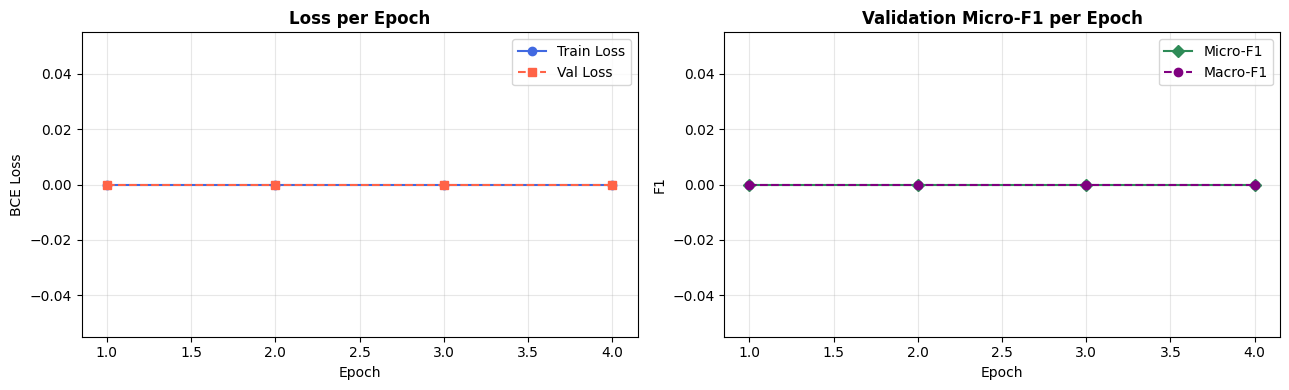

In [19]:
epochs_range = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train Loss', color='royalblue')
axes[0].plot(epochs_range, history['val_loss'],   's--', label='Val Loss',   color='tomato')
axes[0].set_title('Loss per Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history['val_f1_micro'], 'D-', label='Micro-F1', color='seagreen')
axes[1].plot(epochs_range, history['val_f1_macro'], 'o--', label='Macro-F1', color='purple')
axes[1].set_title('Validation Micro-F1 per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()

---
## Step 9 — Test Evaluation (Best Checkpoint)

In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

bert_results = {
    'model':           'BERT fine-tuned + per-label thresholds',
    'precision_micro': precision_score(test_labels, test_pred, average='micro', zero_division=0),
    'recall_micro':    recall_score   (test_labels, test_pred, average='micro', zero_division=0),
    'f1_micro':        f1_score       (test_labels, test_pred, average='micro', zero_division=0),
    'f1_macro':        f1_score       (test_labels, test_pred, average='macro', zero_division=0),
    'f1_weighted':     f1_score       (test_labels, test_pred, average='weighted', zero_division=0),
}

print('=' * 55)
print('   BERT — Final Report (Per-Label Thresholds)')
print('=' * 55)

print(classification_report(
    test_labels,
    test_pred,
    target_names=mlb.classes_,
    zero_division=0
))

print('\nSummary:')
for k, v in bert_results.items():
    if k != 'model':
        print(f'  {k:<22} {v:.4f}')

   BERT — Final Report (Per-Label Thresholds)
                                                                                       precision    recall  f1-score   support

                                                        Account information incorrect       0.17      0.56      0.27       821
                                                             Account status incorrect       0.33      0.39      0.36       722
                              Advertising and marketing, including promotional offers       0.07      0.29      0.11        72
                          Applying for a mortgage or refinancing an existing mortgage       0.16      0.66      0.26        82
                                                    Attempted to collect wrong amount       0.11      0.62      0.18       203
                                                    Attempts to collect debt not owed       0.32      0.67      0.43       808
                                                              Ba

---
## Step 10 — Baseline vs BERT Comparison

In [21]:
baseline_results = {
    'model': 'TF-IDF + LR',
    'precision_micro': experiments[0]['precision_micro'],
    'recall_micro': experiments[0]['recall_micro'],
    'f1_micro': experiments[0]['f1_micro'],
    'f1_macro': experiments[0]['f1_macro'],
    'f1_weighted': experiments[0]['f1_weighted'],
}

                                        precision_micro  recall_micro  f1_micro  f1_macro  f1_weighted
model                                                                                                 
TF-IDF + LR                                      0.2733        0.8802    0.4172    0.2766       0.4986
BERT fine-tuned + per-label thresholds           0.3841        0.6832    0.4918    0.3351       0.5542


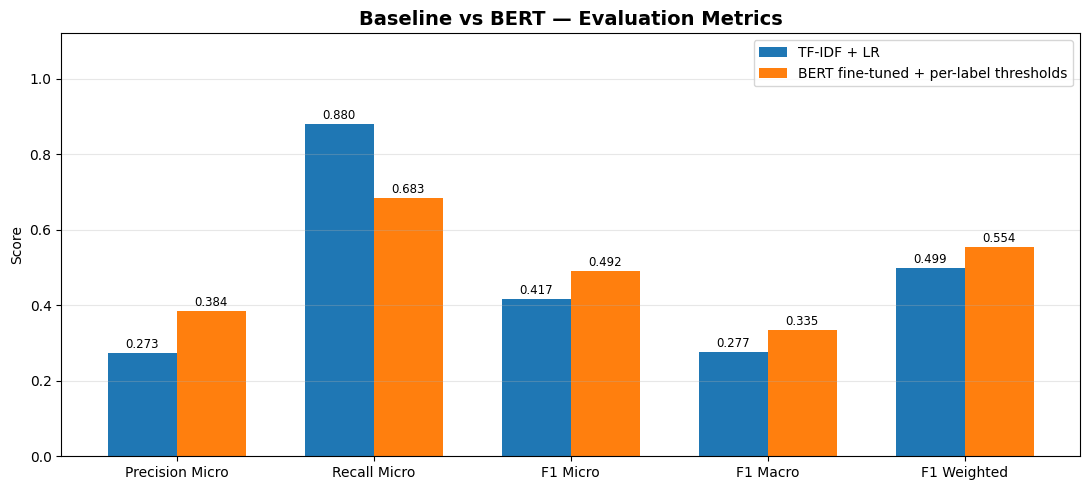

In [22]:
metrics = ['precision_micro', 'recall_micro', 'f1_micro', 'f1_macro', 'f1_weighted']

comparison_df = pd.DataFrame([baseline_results, bert_results]).set_index('model')
print(comparison_df[metrics].round(4).to_string())

x = np.arange(len(metrics))
width = 0.35

baseline_name = comparison_df.index[0]
bert_name = comparison_df.index[1]

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(
    x - width/2,
    comparison_df.loc[baseline_name, metrics],
    width,
    label=baseline_name
)

bars2 = ax.bar(
    x + width/2,
    comparison_df.loc[bert_name, metrics],
    width,
    label=bert_name
)

for bar in list(bars1) + list(bars2):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{bar.get_height():.3f}',
        ha='center',
        va='bottom',
        fontsize=8.5
    )

ax.set_xticks(x)
ax.set_xticklabels([m.replace('_', ' ').title() for m in metrics])
ax.set_ylim(0, 1.12)
ax.set_title('Baseline vs BERT — Evaluation Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120)
plt.show()

---
## Step 11 — Diagnosis: Label Imbalance Analysis

The large gap between **Micro F1 ≈ 0.52** and **Macro F1 ≈ 0.03** is the
primary problem. We verify and quantify the root cause here before fixing it.

**Root cause hypothesis:** a long-tail label distribution where a handful of
large labels dominate training, while rare labels are essentially unlearnable.

### 11.1 — Label Frequency Distribution

Total labels                       : 101
Labels with freq  < 10             : 0
Labels with freq  < 50             : 0
Labels with freq  < 100            : 0
Labels with freq >= 100            : 101

Top-10 most frequent labels:
  Credit reporting or other personal consumer reports  29969
  Incorrect information on your report                24340
  Credit reporting, credit repair services, or other personal consumer reports  19475
  Information belongs to someone else                 13635
  Improper use of your report                         12787
  Debt collection                                     10009
  Reporting company used your report improperly        9297
  Their investigation did not fix an error on your report   7978
  Problem with a company's investigation into an existing problem   6085
  Problem with a credit reporting company's investigation into an existing problem   5866

Bottom-10 least frequent labels:
  Consumer Loan                                         253
  

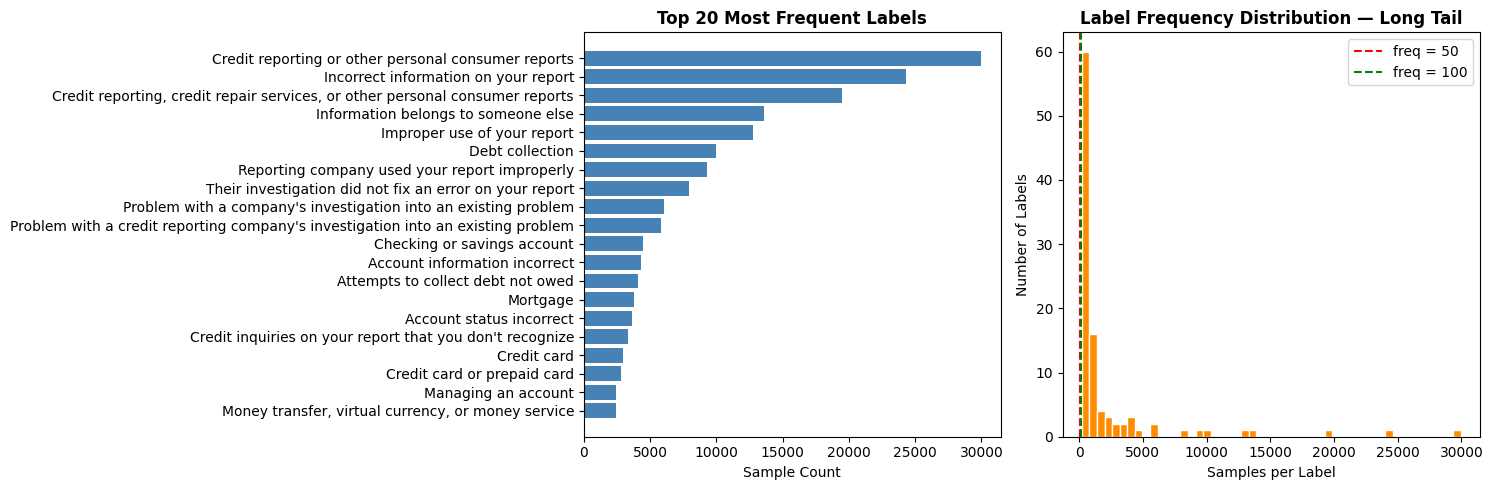

In [23]:
label_freq  = y.sum(axis=0).astype(int)
label_names = np.array(mlb.classes_)
sorted_idx  = np.argsort(label_freq)[::-1]
freq_sorted = label_freq[sorted_idx]
name_sorted = label_names[sorted_idx]

print(f"{'Total labels':<35}: {len(label_freq)}")
print(f"{'Labels with freq  < 10':<35}: {(label_freq < 10).sum()}")
print(f"{'Labels with freq  < 50':<35}: {(label_freq < 50).sum()}")
print(f"{'Labels with freq  < 100':<35}: {(label_freq < 100).sum()}")
print(f"{'Labels with freq >= 100':<35}: {(label_freq >= 100).sum()}")

print("\nTop-10 most frequent labels:")
for n, f in zip(name_sorted[:10], freq_sorted[:10]):
    print(f"  {n:<50} {f:>6}")

print("\nBottom-10 least frequent labels:")
for n, f in zip(name_sorted[-10:], freq_sorted[-10:]):
    print(f"  {n:<50} {f:>6}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart — top 20
axes[0].barh(name_sorted[:20][::-1], freq_sorted[:20][::-1], color='steelblue')
axes[0].set_title('Top 20 Most Frequent Labels', fontweight='bold')
axes[0].set_xlabel('Sample Count')

# Histogram — full distribution
axes[1].hist(label_freq, bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Label Frequency Distribution — Long Tail', fontweight='bold')
axes[1].set_xlabel('Samples per Label')
axes[1].set_ylabel('Number of Labels')
axes[1].axvline(50,  color='red',   linestyle='--', linewidth=1.5, label='freq = 50')
axes[1].axvline(100, color='green', linestyle='--', linewidth=1.5, label='freq = 100')
axes[1].legend()

plt.tight_layout()
plt.show()

### 11.2 — Per-Label F1 Score vs. Frequency (BERT)

A scatter plot of **label frequency vs. label-level F1** confirms the bias:
high-frequency labels score well, rare labels are near zero.

Labels with F1 = 0 : 0 / 101 (0.0%)

Top-10 by frequency:
                                                                           label  frequency  f1_bert
                             Credit reporting or other personal consumer reports      29969 0.730697
                                            Incorrect information on your report      24340 0.660777
    Credit reporting, credit repair services, or other personal consumer reports      19475 0.585038
                                             Information belongs to someone else      13635 0.664374
                                                     Improper use of your report      12787 0.682564
                                                                 Debt collection      10009 0.737272
                                   Reporting company used your report improperly       9297 0.619983
                         Their investigation did not fix an error on your report       7978 0.444921
                 Problem with a c

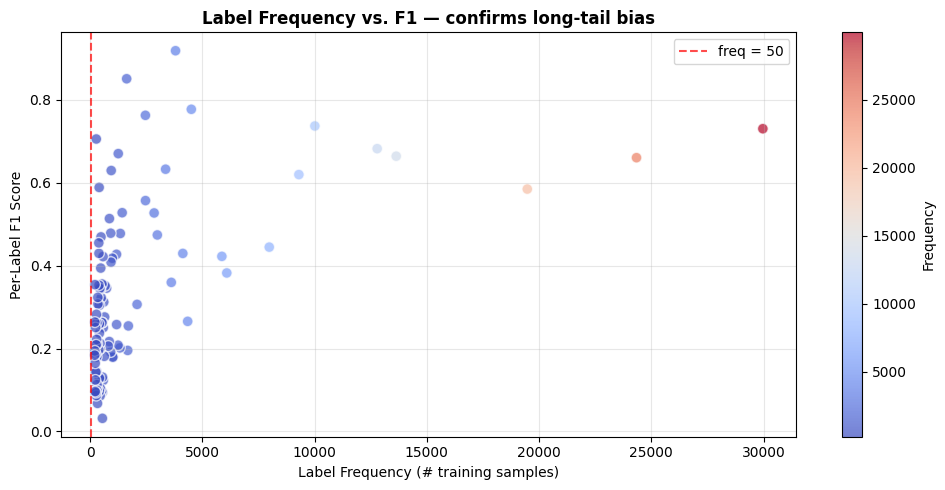

In [24]:
from sklearn.metrics import f1_score

per_label_f1_bert = f1_score(test_labels, test_pred, average=None, zero_division=0)

label_df = pd.DataFrame({
    'label':     mlb.classes_,
    'frequency': label_freq,
    'f1_bert':   per_label_f1_bert,
}).sort_values('frequency', ascending=False)

zero_f1 = (per_label_f1_bert == 0).sum()
pct     = 100 * zero_f1 / len(per_label_f1_bert)

print(f"Labels with F1 = 0 : {zero_f1} / {len(per_label_f1_bert)} ({pct:.1f}%)")

print("\nTop-10 by frequency:")
print(label_df.head(10)[['label','frequency','f1_bert']].to_string(index=False))

plt.figure(figsize=(10, 5))
sc = plt.scatter(
    label_df['frequency'], label_df['f1_bert'],
    c=label_df['frequency'], cmap='coolwarm', alpha=0.7, s=60, edgecolors='white'
)

plt.colorbar(sc, label='Frequency')
plt.axvline(50, color='red', linestyle='--', alpha=0.7, label='freq = 50')

plt.xlabel('Label Frequency (# training samples)')
plt.ylabel('Per-Label F1 Score')
plt.title('Label Frequency vs. F1 — confirms long-tail bias', fontweight='bold')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 12 — Improvement 2: Retrain BERT v2 with Label Filtering + Focal Loss

Two structural changes that require retraining:

| Change | Why |
|--------|-----|
| **Filter rare labels** (`freq < MIN_LABEL_FREQ`) | Labels with very few samples are unlearnable and push Macro F1 to zero |
| **Focal Loss** (`γ = 2`) | Down-weights easy / frequent examples so the model concentrates on hard / rare ones |

### 12.1 — Filter Rare Labels

In [25]:
MIN_LABEL_FREQ = 200

label_freq_full = y.sum(axis=0).astype(int)
keep_mask       = label_freq_full >= MIN_LABEL_FREQ
y_filtered      = y[:, keep_mask]
classes_v2      = mlb.classes_[keep_mask]
NUM_LABELS_V2   = int(keep_mask.sum())

# Drop rows where every remaining label is 0
row_has_label = y_filtered.sum(axis=1) > 0
y_filtered    = y_filtered[row_has_label]
X_filtered    = [t for t, keep in zip(X, row_has_label) if keep]

print(f"MIN_LABEL_FREQ   : {MIN_LABEL_FREQ}")
print(f"Original labels  : {len(mlb.classes_)}")
print(f"Kept labels      : {NUM_LABELS_V2}")
print(f"Dropped labels   : {(~keep_mask).sum()}")
print(f"Rows kept        : {len(X_filtered)} / {len(X)} ({100*len(X_filtered)/len(X):.1f}%)")
print(f"Label matrix v2  : {y_filtered.shape}")

MIN_LABEL_FREQ   : 200
Original labels  : 101
Kept labels      : 101
Dropped labels   : 0
Rows kept        : 81618 / 81618 (100.0%)
Label matrix v2  : (81618, 101)


### 12.2 — Stratified Split (iterative, with fallback)

In [26]:
# Iterative stratified split respects label co-occurrence distributions.
# Requires: pip install scikit-multilearn
try:
    from skmultilearn.model_selection import iterative_train_test_split
    import scipy.sparse as sp

    X_arr = np.array(X_filtered, dtype=object).reshape(-1, 1)
    y_sp  = sp.csr_matrix(y_filtered)

    X_tv, y_tv, X_te_arr, y_te = iterative_train_test_split(X_arr, y_sp, test_size=0.2)
    X_tr_arr, y_tr, X_va_arr, y_va = iterative_train_test_split(X_tv, y_tv, test_size=0.1)

    X_train_v2 = X_tr_arr.flatten().tolist()
    X_val_v2   = X_va_arr.flatten().tolist()
    X_test_v2  = X_te_arr.flatten().tolist()
    Y_train_v2 = y_tr.toarray()
    Y_val_v2   = y_va.toarray()
    Y_test_v2  = y_te.toarray()
    split_method = 'Iterative Stratified Split'

except ImportError:
    print('skmultilearn not found — using random split.')
    print('Install: pip install scikit-multilearn')
    X_tv, X_test_v2, y_tv, Y_test_v2 = train_test_split(
        X_filtered, y_filtered, test_size=0.2, random_state=42)
    X_train_v2, X_val_v2, Y_train_v2, Y_val_v2 = train_test_split(
        X_tv, y_tv, test_size=0.1, random_state=42)
    split_method = 'Random Split (fallback)'

print(f'Split method   : {split_method}')
print(f'X_train_v2 : {len(X_train_v2):>6}  Y: {Y_train_v2.shape}')
print(f'X_val_v2   : {len(X_val_v2):>6}  Y: {Y_val_v2.shape}')
print(f'X_test_v2  : {len(X_test_v2):>6}  Y: {Y_test_v2.shape}')

skmultilearn not found — using random split.
Install: pip install scikit-multilearn
Split method   : Random Split (fallback)
X_train_v2 :  58764  Y: (58764, 101)
X_val_v2   :   6530  Y: (6530, 101)
X_test_v2  :  16324  Y: (16324, 101)


### 12.3 — Focal Loss

Standard BCE treats all examples equally.  
Focal Loss adds a modulating factor `(1 − p_t)^γ` that down-weights
well-classified (easy) examples, forcing the model to focus on hard / rare ones.

In [27]:
import torch.nn.functional as F


class FocalLoss(nn.Module):
    """
    Multi-label Focal Loss.
    FL(p_t) = -(1 - p_t)^gamma * log(p_t)
    gamma=0 reduces to standard BCE.  gamma=2 is the typical default.
    pos_weight optionally handles class-count imbalance on top.
    """

    def __init__(self, gamma: float = 2.0, pos_weight=None):
        super().__init__()
        self.gamma      = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce           = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction='none'
        )
        probs         = torch.sigmoid(logits)
        pt            = torch.where(targets == 1, probs, 1 - probs)
        focal_weight  = (1 - pt) ** self.gamma
        return (focal_weight * bce).mean()

### 12.4 — Retrain BERT v2

In [28]:
# ── DataLoaders v2 ───────────────────────────────────────────────────────
train_loader_v2 = make_loader(X_train_v2, Y_train_v2, shuffle=True)
val_loader_v2   = make_loader(X_val_v2,   Y_val_v2)
test_loader_v2  = make_loader(X_test_v2,  Y_test_v2)

# ── Model v2 (fresh weights, filtered label space) ───────────────────────
model_v2 = BertMultiLabelClassifier(
    model_name=BERT_MODEL_NAME,
    num_labels=NUM_LABELS_V2,
    dropout=DROPOUT_PROB,
).to(DEVICE)

# ── Focal loss + clipped pos_weight ──────────────────────────────────────
lc_v2     = Y_train_v2.sum(axis=0)
nc_v2     = len(Y_train_v2) - lc_v2
pw_np_v2  = nc_v2 / (lc_v2 + 1e-8)
pw_np_v2  = np.clip(pw_np_v2, 1, 20)
pw_v2     = torch.tensor(pw_np_v2, dtype=torch.float).to(DEVICE)

criterion_v2 = FocalLoss(gamma=2.0, pos_weight=pw_v2)

# ── Optimizer & scheduler ────────────────────────────────────────────────
no_decay_v2 = ['bias', 'LayerNorm.weight']
params_v2 = [
    {
        'params': [p for n, p in model_v2.named_parameters() if not any(nd in n for nd in no_decay_v2)],
        'weight_decay': 0.01
    },
    {
        'params': [p for n, p in model_v2.named_parameters() if any(nd in n for nd in no_decay_v2)],
        'weight_decay': 0.0
    },
]

optimizer_v2 = AdamW(params_v2, lr=LEARNING_RATE)
total_v2     = len(train_loader_v2) * NUM_EPOCHS
warmup_v2    = int(total_v2 * WARMUP_RATIO)
scheduler_v2 = get_linear_schedule_with_warmup(optimizer_v2, warmup_v2, total_v2)

best_model_path_v2 = 'bert2_focal_filtered200.pt'
history_v2 = {
    'train_loss': [],
    'val_loss': [],
    'val_f1_micro': [],
    'val_f1_macro': []
}
best_val_f1_v2 = 0.0


def evaluate_v2(mdl, loader, crit, threshold=THRESHOLD):
    mdl.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            lbls = batch['labels'].to(DEVICE)

            logits = mdl(ids, mask)
            total_loss += crit(logits, lbls).item()

            preds = (torch.sigmoid(logits) >= threshold).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(lbls.cpu().numpy())

    preds_all  = np.vstack(all_preds)
    labels_all = np.vstack(all_labels)

    return (
        total_loss / len(loader),
        f1_score(labels_all, preds_all, average='micro', zero_division=0),
        f1_score(labels_all, preds_all, average='macro', zero_division=0),
        preds_all,
        labels_all
    )


# ── Training loop ────────────────────────────────────────────────────────
if os.path.exists(best_model_path_v2):
    print(f'✓ BERT v2 found — skipping training, loading from {best_model_path_v2}')
    model_v2.load_state_dict(torch.load(best_model_path_v2, map_location=DEVICE))
    history_v2 = {'train_loss': [0]*NUM_EPOCHS, 'val_loss': [0]*NUM_EPOCHS,
                  'val_f1_micro': [0]*NUM_EPOCHS, 'val_f1_macro': [0]*NUM_EPOCHS}
else:
    for epoch in range(1, NUM_EPOCHS + 1):
        model_v2.train()
        running_loss = 0.0
    
        for step, batch in enumerate(train_loader_v2, 1):
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            lbls = batch['labels'].to(DEVICE)
    
            optimizer_v2.zero_grad(set_to_none=True)
            logits = model_v2(ids, mask)
            loss   = criterion_v2(logits, lbls)
            loss.backward()
    
            nn.utils.clip_grad_norm_(model_v2.parameters(), max_norm=1.0)
            optimizer_v2.step()
            scheduler_v2.step()
    
            running_loss += loss.item()
    
            if step % 20 == 0 or step == len(train_loader_v2):
                print(
                    f'  Epoch {epoch}/{NUM_EPOCHS}  '
                    f'Step {step:>4}/{len(train_loader_v2)}  '
                    f'Loss {running_loss/step:.4f}',
                    end='\r'
                )
    
        train_loss_v2 = running_loss / len(train_loader_v2)
        val_loss_v2, val_f1_micro_v2, val_f1_macro_v2, _, _ = evaluate_v2(
            model_v2, val_loader_v2, criterion_v2
        )
    
        history_v2['train_loss'].append(train_loss_v2)
        history_v2['val_loss'].append(val_loss_v2)
        history_v2['val_f1_micro'].append(val_f1_micro_v2)
        history_v2['val_f1_macro'].append(val_f1_macro_v2)
    
        print(
            f'\nEpoch {epoch}/{NUM_EPOCHS}  '
            f'Train Loss: {train_loss_v2:.4f}  '
            f'Val Loss: {val_loss_v2:.4f}  '
            f'Val micro-F1: {val_f1_micro_v2:.4f}  '
            f'Val macro-F1: {val_f1_macro_v2:.4f}'
        )
    
        if val_f1_micro_v2 > best_val_f1_v2:
            best_val_f1_v2 = val_f1_micro_v2
            torch.save(model_v2.state_dict(), best_model_path_v2)
            print(f'  ✔ Best v2 model saved (val micro-F1={best_val_f1_v2:.4f})')

print('\nTraining v2 complete.')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


✓ BERT v2 found — skipping training, loading from bert2_focal_filtered200.pt


/tmp/ipykernel_831/3154626206.py:83: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_v2.load_state_dict(torch.load(best_model_path_v2, map_location=DEVICE))



Training v2 complete.


### 12.5 — Evaluate BERT v2 on Test Set

In [29]:
model_v2.load_state_dict(torch.load(best_model_path_v2, map_location=DEVICE))
_, _, _, Y_pred_v2, Y_true_v2 = evaluate_v2(model_v2, test_loader_v2, criterion_v2)

bert_v2_results = {
    'model':           f'BERT v2 (Filtered + Focal, th={THRESHOLD})',
    'precision_micro': precision_score(Y_true_v2, Y_pred_v2, average='micro', zero_division=0),
    'recall_micro':    recall_score   (Y_true_v2, Y_pred_v2, average='micro', zero_division=0),
    'f1_micro':        f1_score       (Y_true_v2, Y_pred_v2, average='micro', zero_division=0),
    'f1_macro':        f1_score       (Y_true_v2, Y_pred_v2, average='macro', zero_division=0),
    'f1_weighted':     f1_score       (Y_true_v2, Y_pred_v2, average='weighted', zero_division=0),
}

print('=' * 60)
print('   BERT v2 — Per-Label Classification Report')
print('=' * 60)
print(classification_report(
    Y_true_v2,
    Y_pred_v2,
    target_names=classes_v2,
    zero_division=0
))

print('\nSummary:')
for k, v in bert_v2_results.items():
    if k != 'model':
        print(f'  {k:<22} {v:.4f}')

/tmp/ipykernel_831/3457799548.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_v2.load_state_dict(torch.load(best_model_path_v2, map_location=DEVICE))


   BERT v2 — Per-Label Classification Report
                                                                                       precision    recall  f1-score   support

                                                        Account information incorrect       0.14      0.80      0.24       821
                                                             Account status incorrect       0.17      0.79      0.27       722
                              Advertising and marketing, including promotional offers       0.17      0.78      0.28        72
                          Applying for a mortgage or refinancing an existing mortgage       0.12      0.94      0.22        82
                                                    Attempted to collect wrong amount       0.10      0.68      0.18       203
                                                    Attempts to collect debt not owed       0.25      0.78      0.37       808
                                                              Ban

### BERT v2 + Per-Label Threshold Optimization

In [30]:
# ── BERT v2 + Per-Label Threshold Optimization ───────────────────────────

# Step 1: جمع احتمالات الـ validation من model_v2
model_v2.load_state_dict(torch.load(best_model_path_v2, map_location=DEVICE))
model_v2.eval()

all_val_probs_v2, all_val_labels_v2 = [], []
with torch.no_grad():
    for batch in val_loader_v2:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        logits = model_v2(ids, mask)
        probs  = torch.sigmoid(logits).cpu().numpy()
        all_val_probs_v2.append(probs)
        all_val_labels_v2.append(batch['labels'].numpy())

val_probs_v2  = np.vstack(all_val_probs_v2)
val_labels_v2 = np.vstack(all_val_labels_v2)

# Step 2: Per-label threshold optimization
best_thresholds_v2 = []
for j in range(val_probs_v2.shape[1]):
    y_true = val_labels_v2[:, j]
    y_prob = val_probs_v2[:, j]
    if y_true.sum() == 0:
        best_thresholds_v2.append(0.5)
        continue
    best_th, best_f1 = 0.5, -1.0
    for th in np.arange(0.10, 0.91, 0.05):
        f1 = f1_score(y_true, (y_prob >= th).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_th = f1, th
    best_thresholds_v2.append(best_th)

print(f"Threshold optimization done. Example thresholds: {best_thresholds_v2[:5]}")

# Step 3: تطبيق على test set
all_test_probs_v2, all_test_labels_v2 = [], []
model_v2.eval()
with torch.no_grad():
    for batch in test_loader_v2:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        logits = model_v2(ids, mask)
        probs  = torch.sigmoid(logits).cpu().numpy()
        all_test_probs_v2.append(probs)
        all_test_labels_v2.append(batch['labels'].numpy())

test_probs_v2_arr  = np.vstack(all_test_probs_v2)
test_labels_v2_arr = np.vstack(all_test_labels_v2)

thr_arr_v2 = np.array(best_thresholds_v2).reshape(1, -1)
test_pred_v2_tuned = (test_probs_v2_arr >= thr_arr_v2).astype(int)

# Step 4: النتائج
bert_v2_tuned_results = {
    'model':           'BERT v2 (Focal + Filtered + Per-Label Thresholds)',
    'precision_micro': precision_score(test_labels_v2_arr, test_pred_v2_tuned, average='micro', zero_division=0),
    'recall_micro':    recall_score   (test_labels_v2_arr, test_pred_v2_tuned, average='micro', zero_division=0),
    'f1_micro':        f1_score       (test_labels_v2_arr, test_pred_v2_tuned, average='micro', zero_division=0),
    'f1_macro':        f1_score       (test_labels_v2_arr, test_pred_v2_tuned, average='macro', zero_division=0),
    'f1_weighted':     f1_score       (test_labels_v2_arr, test_pred_v2_tuned, average='weighted', zero_division=0),
}
print("\nBERT v2 + Per-Label Thresholds Results:")
for k, v in bert_v2_tuned_results.items():
    if k != 'model':
        print(f"  {k}: {v:.4f}")

/tmp/ipykernel_831/2984455818.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_v2.load_state_dict(torch.load(best_model_path_v2, map_location=DEVICE))


Threshold optimization done. Example thresholds: [np.float64(0.6000000000000002), np.float64(0.6000000000000002), np.float64(0.6000000000000002), np.float64(0.6000000000000002), np.float64(0.6000000000000002)]

BERT v2 + Per-Label Thresholds Results:
  precision_micro: 0.4575
  recall_micro: 0.6768
  f1_micro: 0.5460
  f1_macro: 0.3797
  f1_weighted: 0.5933


## Step 13 — Final Comparison: All Models

FINAL COMPARISON
                                                   precision_micro  recall_micro  f1_micro  f1_macro  f1_weighted
model                                                                                                            
TF-IDF + LR                                                 0.2733        0.8802    0.4172    0.2766       0.4986
BERT fine-tuned + per-label thresholds                      0.3841        0.6832    0.4918    0.3351       0.5542
BERT + Tuned Thresholds                                     0.4588        0.5559    0.5027    0.2682       0.5087
BERT v2 (Filtered + Focal, th=0.5)                          0.3245        0.8123    0.4637    0.3128       0.5449
BERT v2 (Focal + Filtered + Per-Label Thresholds)           0.4575        0.6768    0.5460    0.3797       0.5933


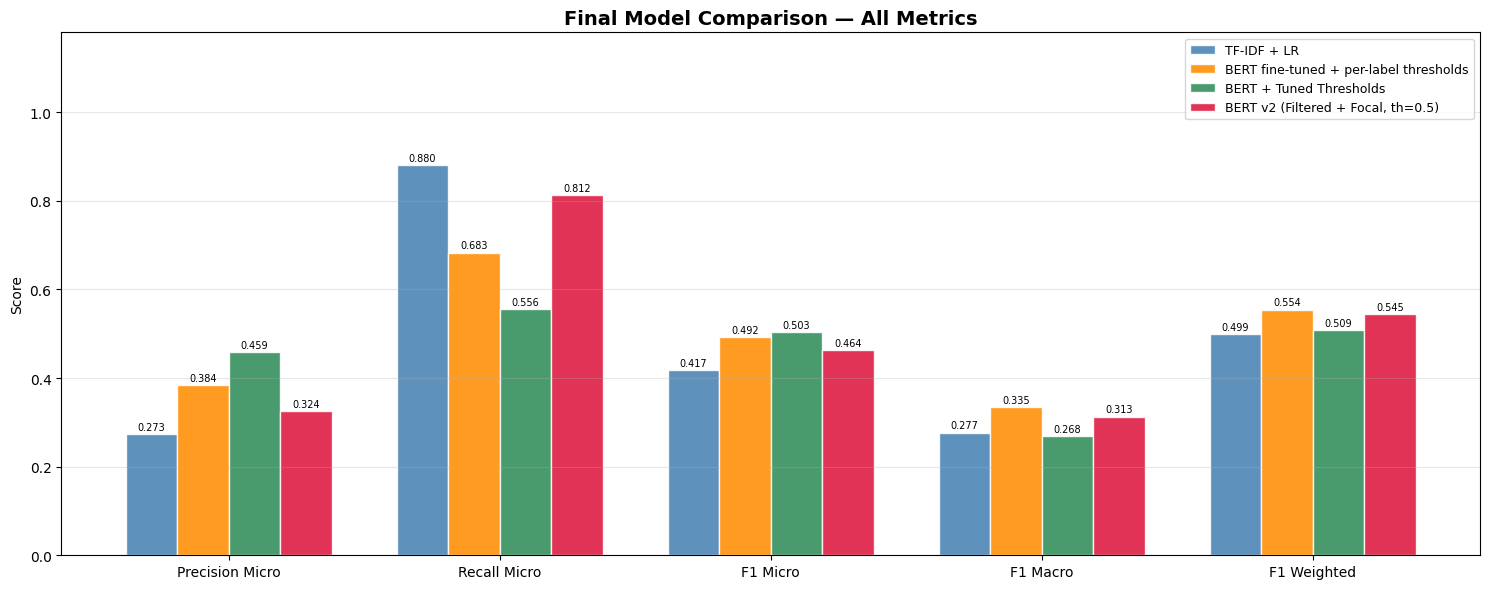


=== Macro F1 — Improvement over TF-IDF baseline ===
  TF-IDF + LR                         macro-F1: 0.2766  ▲ +0.0000  (+0.0%)
  BERT fine-tuned + per-label thresholds macro-F1: 0.3351  ▲ +0.0585  (+21.2%)
  BERT + Tuned Thresholds             macro-F1: 0.2682  ▼ -0.0084  (-3.0%)
  BERT v2 (Filtered + Focal, th=0.5)  macro-F1: 0.3128  ▲ +0.0362  (+13.1%)
  BERT v2 (Focal + Filtered + Per-Label Thresholds) macro-F1: 0.3797  ▲ +0.1031  (+37.3%)

NOTE:
BERT v2 results are obtained on a filtered label space, so direct comparison with earlier models should be interpreted with caution.


In [31]:
metrics = ['precision_micro', 'recall_micro', 'f1_micro', 'f1_macro', 'f1_weighted']

all_results = [baseline_results, bert_results, tuned_results, bert_v2_results, bert_v2_tuned_results]
final_df = pd.DataFrame(all_results).set_index('model')

print('=' * 80)
print('FINAL COMPARISON')
print('=' * 80)
print(final_df[metrics].round(4).to_string())

# ── Bar chart ─────────────────────────────────────────────────────────────
x = np.arange(len(metrics))
width = 0.19
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']

fig, ax = plt.subplots(figsize=(15, 6))
for i, (mdl, color) in enumerate(zip(final_df.index, colors)):
    vals = final_df.loc[mdl, metrics].values
    bars = ax.bar(
        x + (i - 1.5) * width,
        vals,
        width,
        label=mdl,
        color=color,
        edgecolor='white',
        alpha=0.87
    )
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center',
            va='bottom',
            fontsize=7
        )

ax.set_xticks(x)
ax.set_xticklabels([m.replace('_', ' ').title() for m in metrics])
ax.set_ylim(0, 1.18)
ax.set_title('Final Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=120)
plt.show()

# ── Macro F1 focus ────────────────────────────────────────────────────────
print('\n=== Macro F1 — Improvement over TF-IDF baseline ===')
base_macro = baseline_results['f1_macro']
for r in all_results:
    delta = r['f1_macro'] - base_macro
    arrow = '▲' if delta >= 0 else '▼'
    pct = 100 * delta / (base_macro + 1e-9)
    print(f"  {r['model']:<35} macro-F1: {r['f1_macro']:.4f}  {arrow} {delta:+.4f}  ({pct:+.1f}%)")

print("\nNOTE:")
print("BERT v2 results are obtained on a filtered label space, so direct comparison with earlier models should be interpreted with caution.")

---
## Step 14 — Save Model & Results

In [32]:
import os
import json
import shutil
import pandas as pd
import torch

OUTPUT_DIR = 'complaint_bert_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================================================
# Save BERT v1
# =========================================================
v1_dir = os.path.join(OUTPUT_DIR, 'bert_v1')
os.makedirs(v1_dir, exist_ok=True)

model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
torch.save(model.state_dict(), os.path.join(v1_dir, 'bert_v1_model.pt'))
tokenizer.save_pretrained(os.path.join(v1_dir, 'tokenizer'))

with open(os.path.join(v1_dir, 'label_classes_v1.json'), 'w') as f:
    json.dump(list(mlb.classes_), f, indent=2)

pd.DataFrame(history).to_csv(os.path.join(v1_dir, 'training_history_v1.csv'), index=False)

# =========================================================
# Save BERT v2
# =========================================================
v2_dir = os.path.join(OUTPUT_DIR, 'bert_v2')
os.makedirs(v2_dir, exist_ok=True)

model_v2.load_state_dict(torch.load(best_model_path_v2, map_location=DEVICE))
torch.save(model_v2.state_dict(), os.path.join(v2_dir, 'bert_v2_model.pt'))
tokenizer.save_pretrained(os.path.join(v2_dir, 'tokenizer'))

with open(os.path.join(v2_dir, 'label_classes_v2.json'), 'w') as f:
    json.dump(list(classes_v2), f, indent=2)

pd.DataFrame(history_v2).to_csv(os.path.join(v2_dir, 'training_history_v2.csv'), index=False)

# =========================================================
# Save comparison tables
# =========================================================
comparison_df[metrics].round(4).reset_index().to_csv(
    os.path.join(OUTPUT_DIR, 'evaluation_results.csv'),
    index=False
)

final_df[metrics].round(4).reset_index().to_csv(
    os.path.join(OUTPUT_DIR, 'final_comparison.csv'),
    index=False
)

# =========================================================
# Save plots safely (copy, not rename)
# =========================================================
for fname in [
    'training_curves.png',
    'model_comparison.png',
    'final_comparison.png'
]:
    if os.path.exists(fname):
        shutil.copy2(fname, os.path.join(OUTPUT_DIR, fname))

print(f'\nAll outputs saved to: {OUTPUT_DIR}/')
print(os.listdir(OUTPUT_DIR))

# =========================================================
# Copy outputs to Google Drive
# =========================================================
if 'DRIVE_PROJECT_PATH' in globals():
    DRIVE_OUTPUT_DIR = f'{DRIVE_PROJECT_PATH}/complaint_bert_output'
    shutil.copytree(OUTPUT_DIR, DRIVE_OUTPUT_DIR, dirs_exist_ok=True)
    print(f'\nOutputs also saved to Drive: {DRIVE_OUTPUT_DIR}')
else:
    print("⚠️ DRIVE_PROJECT_PATH not defined — skipping Drive backup")

/tmp/ipykernel_831/217431255.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
/tmp/ipykernel_831/


All outputs saved to: complaint_bert_output/
['bert_v2', '.ipynb_checkpoints', 'bert_v1', 'training_curves.png', 'final_comparison.png', 'model_comparison.png', 'evaluation_results.csv', 'final_comparison.csv']
⚠️ DRIVE_PROJECT_PATH not defined — skipping Drive backup


---
## Step 15 — Inference on New Complaints


## 15.1 — BERT v1 + per-label thresholds

In [33]:
def clean_text(text: str) -> str:
    """Basic text normalisation before inference."""
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def predict_complaint_v1(text: str) -> dict:
    """Predict labels for a single complaint using BERT v1 + per-label thresholds."""
    model.eval()

    enc = tokenizer(
        clean_text(text),
        max_length=MAX_SEQ_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    )

    with torch.no_grad():
        logits = model(enc['input_ids'].to(DEVICE), enc['attention_mask'].to(DEVICE))
        probs = torch.sigmoid(logits).cpu().numpy().flatten()

    thresholds = np.array(best_thresholds)  # per-label thresholds from v1
    predicted = [lbl for lbl, p, th in zip(mlb.classes_, probs, thresholds) if p >= th]

    return {
        'text': text,
        'labels': predicted if predicted else ['other'],
        'scores': {lbl: round(float(p), 3) for lbl, p in zip(mlb.classes_, probs)},
    }


# Demo predictions
test_complaints = [
    "A debt collector keeps calling me about a debt that is not mine.",
    "My credit report shows accounts that do not belong to me.",
    "My mortgage servicer charged fees I do not recognize.",
    "I made my student loan payment, but it was not reflected in my account.",
    "There is an unauthorized transaction on my credit card."
]

for complaint in test_complaints:
    result = predict_complaint_v1(complaint)
    print(f"Text   : {result['text'][:80]}...")
    print(f"Labels : {result['labels']}")
    print(f"Scores : { {k: v for k, v in result['scores'].items() if v > 0.1} }")
    print('-' * 70)

Text   : A debt collector keeps calling me about a debt that is not mine....
Labels : ['Communication tactics', 'Debt collection', 'Debt is not mine', 'False statements or representation', 'Frequent or repeated calls', 'Took or threatened to take negative or legal action', 'You told them to stop contacting you, but they keep trying']
Scores : {'Attempted to collect wrong amount': 0.457, 'Attempts to collect debt not owed': 0.748, 'Communication tactics': 0.919, "Cont'd attempts collect debt not owed": 0.435, 'Debt collection': 0.984, 'Debt is not mine': 0.327, 'Debt is not yours': 0.609, 'Debt was paid': 0.499, 'Debt was result of identity theft': 0.208, "Didn't receive enough information to verify debt": 0.395, "Didn't receive notice of right to dispute": 0.345, 'Disclosure verification of debt': 0.237, 'False statements or representation': 0.687, 'Frequent or repeated calls': 0.825, 'Money transfer, virtual currency, or money service': 0.117, 'Payday loan, title loan, or personal loa


## 15.2 — BERT v2

In [34]:
def predict_complaint_v2(text: str, threshold: float = THRESHOLD) -> dict:
    """Predict labels for a single complaint using BERT v2."""
    model_v2.eval()

    enc = tokenizer(
        clean_text(text),
        max_length=MAX_SEQ_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    )

    with torch.no_grad():
        logits = model_v2(enc['input_ids'].to(DEVICE), enc['attention_mask'].to(DEVICE))
        probs = torch.sigmoid(logits).cpu().numpy().flatten()

    predicted = [lbl for lbl, p in zip(classes_v2, probs) if p >= threshold]

    return {
        'text': text,
        'labels': predicted if predicted else ['other'],
        'scores': {lbl: round(float(p), 3) for lbl, p in zip(classes_v2, probs)},
    }


# تأكد أنك محمّل أفضل موديل v2
model_v2.load_state_dict(torch.load(best_model_path_v2, map_location=DEVICE))

# Demo predictions
test_complaints2 = [
    "A debt collector keeps calling me about a debt that is not mine.",
    "My credit report shows accounts that do not belong to me.",
    "My mortgage servicer charged fees I do not recognize.",
    "I made my student loan payment, but it was not reflected in my account.",
    "There is an unauthorized transaction on my credit card."
]

for complaint2 in test_complaints2:
    result2 = predict_complaint_v2(complaint2)
    print(f"Text   : {result2['text'][:80]}...")
    print(f"Labels : {result2['labels']}")
    print(f"Scores : { {k: v for k, v in result2['scores'].items() if v > 0.1} }")
    print('-' * 70)

/tmp/ipykernel_831/1151047274.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_v2.load_state_dict(torch.load(best_model_path_v2, map_location=DEVICE))


Text   : A debt collector keeps calling me about a debt that is not mine....
Labels : ['Attempts to collect debt not owed', 'Communication tactics', "Cont'd attempts collect debt not owed", 'Debt collection', 'Debt is not yours', 'Debt was result of identity theft', 'Frequent or repeated calls', 'Took or threatened to take negative or legal action', 'Written notification about debt', 'You told them to stop contacting you, but they keep trying']
Scores : {'Account information incorrect': 0.176, 'Account status incorrect': 0.137, 'Applying for a mortgage or refinancing an existing mortgage': 0.111, 'Attempted to collect wrong amount': 0.4, 'Attempts to collect debt not owed': 0.7, 'Bank account or service': 0.124, "Charged fees or interest you didn't expect": 0.111, 'Checking or savings account': 0.201, 'Closing an account': 0.107, 'Closing on a mortgage': 0.116, 'Communication tactics': 0.643, 'Company closed your account': 0.104, 'Consumer Loan': 0.172, "Cont'd attempts collect debt no